Download EMNIST dataset

In [16]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=True,
    download=True,
    transform=transform
)

print(f"Total samples = {len(dataset)}")
print(f"Number of classes = {len(dataset.classes)}")
print(f"Image shape = {dataset[0][0].shape}")

Total samples = 112800
Number of classes = 47
Image shape = torch.Size([1, 28, 28])


Explore the dataset.

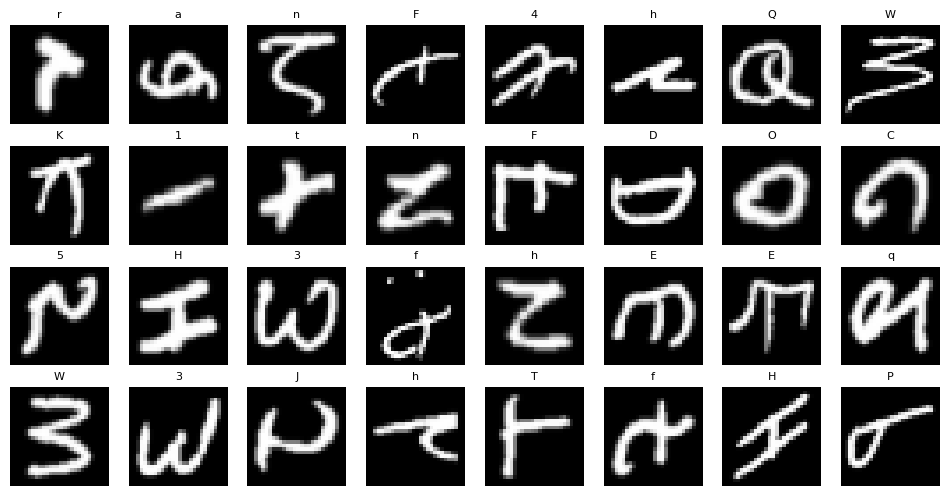

In [17]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image, label = dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(dataset.classes[label], fontsize=8)
    ax.axis('off')
plt.show()

CNN

In [18]:
import torch
import torch.nn as nn

class MathSymbolCNN(nn.Module):
    def __init__(self, num_classes=47):
        super(MathSymbolCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),     # 28 x 28 -> 14 x 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)      # 14 x 14 -> 7 x 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

model = MathSymbolCNN()
print(model)

MathSymbolCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=47, bias=True)
  )
)


Train

In [19]:
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")

model = MathSymbolCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = (correct / total) * 100

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = (val_correct / val_total) * 100


    print(f"{epoch+1} of {EPOCHS}\tTrain Loss: {train_loss/len(train_loader)}\tTrain accuracy: {train_acc}\tVal accuracy: {val_acc}")

torch.save(model.state_dict(), 'math_symbol_cnn.pth')

Device: cuda
1 of 10	Train Loss: 1.1011087146211178	Train accuracy: 66.53479609929079	Val accuracy: 83.35106382978724
2 of 10	Train Loss: 0.6495911636251084	Train accuracy: 78.53834219858156	Val accuracy: 84.97340425531915
3 of 10	Train Loss: 0.5617297404412682	Train accuracy: 81.13142730496455	Val accuracy: 86.09042553191489
4 of 10	Train Loss: 0.5096679471168958	Train accuracy: 82.635195035461	Val accuracy: 86.79521276595744
5 of 10	Train Loss: 0.4762944438250352	Train accuracy: 83.74556737588652	Val accuracy: 87.11436170212767
6 of 10	Train Loss: 0.4443101394895121	Train accuracy: 84.54011524822695	Val accuracy: 87.75265957446808
7 of 10	Train Loss: 0.4200187675285001	Train accuracy: 85.25044326241135	Val accuracy: 87.10992907801418
8 of 10	Train Loss: 0.39893528561220104	Train accuracy: 85.75576241134752	Val accuracy: 87.84574468085107
9 of 10	Train Loss: 0.38627301428123567	Train accuracy: 86.29875886524823	Val accuracy: 87.59308510638299
10 of 10	Train Loss: 0.36911933934646296	T

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

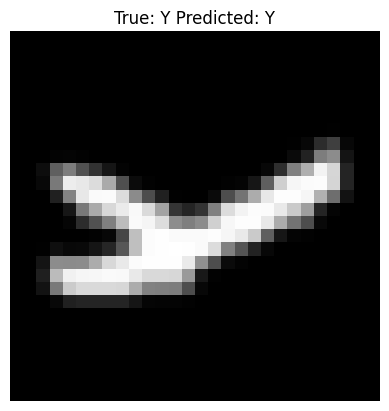

In [32]:
model.eval()
image, label = val_dataset[5]
image_input = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_input)
    _, predicted = torch.max(output, 1)


plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True: {dataset.classes[label]} Predicted: {dataset.classes[predicted.item()]}")
plt.axis('off')